# Pangenome comparison — pang_82 (old) vs pang_135 (new)

Old: `/global/home/users/tbellg/scratch/pang/pang_1001gplus/pang/output/pang_1001gplus_82acc.*`  (82 cactus founders)

New: `/global/home/users/tbellg/scratch/pang/pang_1001gplus/pang_all/output/pang_1001gplus_all.*` (135 cactus founders, finished 2026-05-01)

All metrics live in `pangenome_comparison/output/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('../output')
PANEL_ORDER = ['pang_82', 'pang_135']
PANEL_COLORS = {'pang_82': '#7f8da6', 'pang_135': '#1f4e79', 'pang_135_raw': '#9ec5e8'}
PANEL_LABELS = {'pang_82': '82 founders (old)', 'pang_135': '135 founders (new, filtered)', 'pang_135_raw': '135 founders (new, raw)'}

panel_summary = pd.read_csv(OUT/'panel_summary.tsv', sep='\t')
file_sizes    = pd.read_csv(OUT/'file_sizes.tsv',    sep='\t')
per_chrom     = pd.read_csv(OUT/'per_chrom_records.tsv', sep='\t')
gfa_topo      = pd.read_csv(OUT/'gfa_topology.tsv',  sep='\t')

sc_82  = pd.read_csv(OUT/'pang_82.size_class.tsv',  sep='\t')
sc_135 = pd.read_csv(OUT/'pang_135.size_class.tsv', sep='\t')
sc_135_raw = pd.read_csv(OUT/'pang_135_raw.size_class.tsv', sep='\t')
size_class_all = pd.concat([sc_82, sc_135, sc_135_raw], ignore_index=True)

panel_summary

,panel,n_samples,n_records_filtered,n_records_raw
0,pang_82,82,4450411,NaN
1,pang_135,135,5214959,7860711.0


## 1. Headline: samples + records

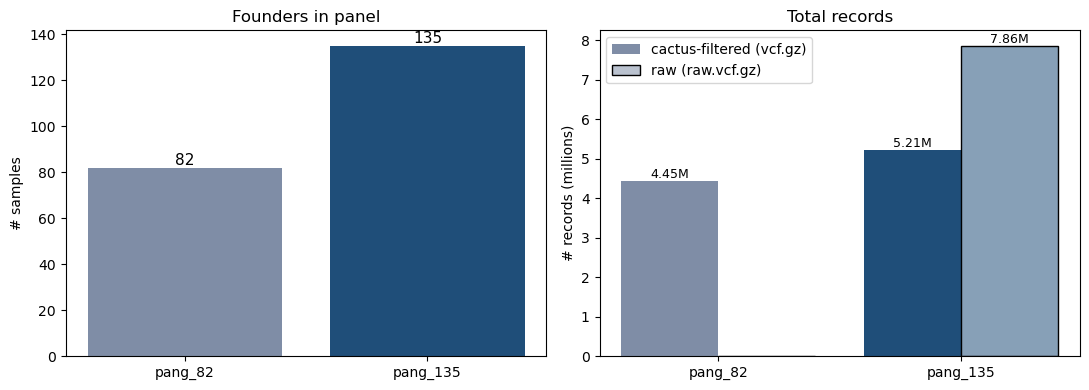

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(panel_summary['panel'], panel_summary['n_samples'],
            color=[PANEL_COLORS[p] for p in panel_summary['panel']])
axes[0].set_title('Founders in panel')
axes[0].set_ylabel('# samples')
for i, v in enumerate(panel_summary['n_samples']):
    axes[0].text(i, v, f'{v}', ha='center', va='bottom', fontsize=11)

x = np.arange(2)
axes[1].bar(x - 0.2, panel_summary['n_records_filtered']/1e6, width=0.4,
            color=[PANEL_COLORS[p] for p in panel_summary['panel']],
            label='cactus-filtered (vcf.gz)')
raw_vals = panel_summary['n_records_raw'].apply(lambda v: v if pd.notna(v) and v != 'NA' else 0).astype(float) / 1e6
axes[1].bar(x + 0.2, raw_vals, width=0.4, color=[PANEL_COLORS[p]+'88' for p in panel_summary['panel']],
            edgecolor='black', label='raw (raw.vcf.gz)')
axes[1].set_xticks(x); axes[1].set_xticklabels(panel_summary['panel'])
axes[1].set_title('Total records')
axes[1].set_ylabel('# records (millions)')
axes[1].legend(loc='upper left')
for i, (f, r) in enumerate(zip(panel_summary['n_records_filtered'], raw_vals)):
    axes[1].text(i - 0.2, f/1e6, f'{f/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
    if r > 0:
        axes[1].text(i + 0.2, r,        f'{r:.2f}M',  ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 2. File sizes by artifact (MB)

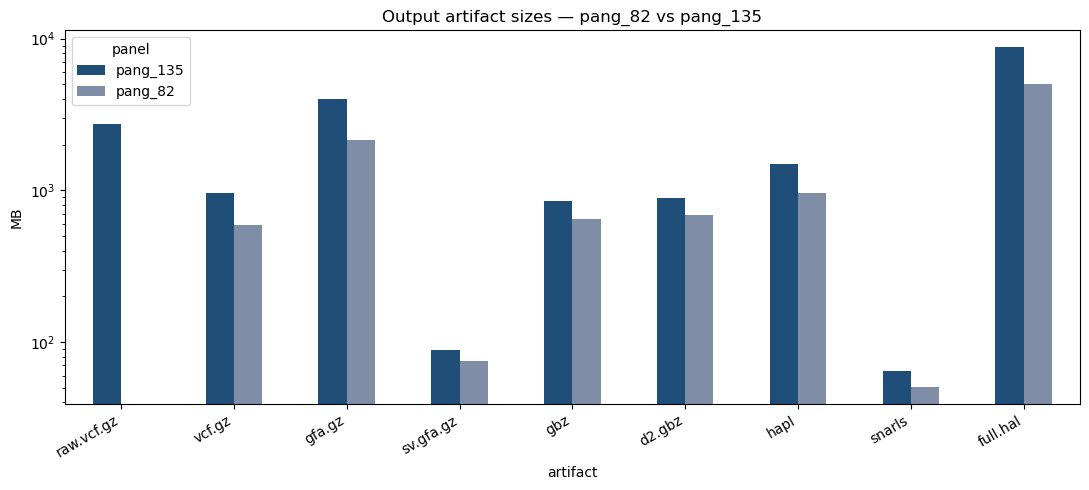

panel,pang_82,pang_135,fold_135_vs_82
artifact,,,
raw.vcf.gz,NaN,2730.15,NaN
vcf.gz,587.58,956.44,1.63
gfa.gz,2132.89,4020.17,1.88
sv.gfa.gz,75.08,88.20,1.17
gbz,650.77,848.08,1.30
d2.gbz,686.63,892.39,1.30
hapl,957.36,1485.00,1.55
snarls,50.56,64.88,1.28
full.hal,4989.55,8766.46,1.76


In [3]:
fs = file_sizes.copy()
fs['MB'] = fs['bytes'] / 1024 / 1024
wide = fs.pivot(index='artifact', columns='panel', values='MB').reindex(
    ['raw.vcf.gz','vcf.gz','gfa.gz','sv.gfa.gz','gbz','d2.gbz','hapl','snarls','full.hal'])
ax = wide.plot(kind='bar', figsize=(11, 5),
               color=[PANEL_COLORS[c] for c in wide.columns])
ax.set_title('Output artifact sizes — pang_82 vs pang_135')
ax.set_ylabel('MB')
ax.set_xlabel('artifact')
ax.set_yscale('log')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

# Side-by-side fold change
fc = wide.copy()
fc['fold_135_vs_82'] = fc['pang_135'] / fc['pang_82']
fc[['pang_82', 'pang_135', 'fold_135_vs_82']].round(2)

## 3. Per-chromosome record counts (cactus-filtered VCF)

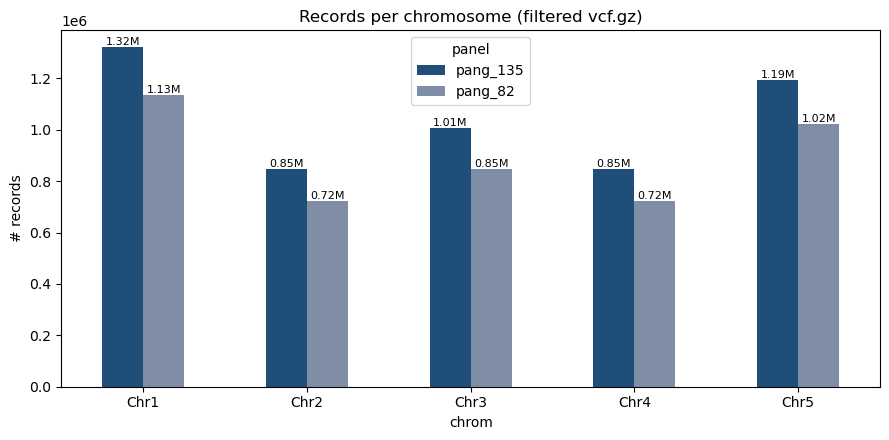

panel,pang_135,pang_82
chrom,,
Chr1,1320800,1133581
Chr2,846877,723767
Chr3,1005720,848020
Chr4,848811,724507
Chr5,1192751,1020536


In [4]:
pc = per_chrom.copy()
pc_wide = pc.pivot(index='chrom', columns='panel', values='n_records')
ax = pc_wide.plot(kind='bar', figsize=(9, 4.5),
                  color=[PANEL_COLORS[c] for c in pc_wide.columns])
ax.set_title('Records per chromosome (filtered vcf.gz)')
ax.set_ylabel('# records')
for i, chrom in enumerate(pc_wide.index):
    for j, panel in enumerate(pc_wide.columns):
        v = pc_wide.loc[chrom, panel]
        ax.text(i + (j-0.5)*0.25, v, f'{v/1e6:.2f}M', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
pc_wide

## 4. Size-class breakdown (per ALT allele)

Each cactus bubble can have many ALT alleles — for genotyping this is the right unit. Size class on `max(ref_len, alt_len)`:
- **SNP**: ref_len == 1 and alt_len == 1
- **small_indel**: < 50 bp
- **small_sv**: 50–500 bp
- **medium_sv**: 500–5000 bp
- **large_sv**: ≥ 5000 bp

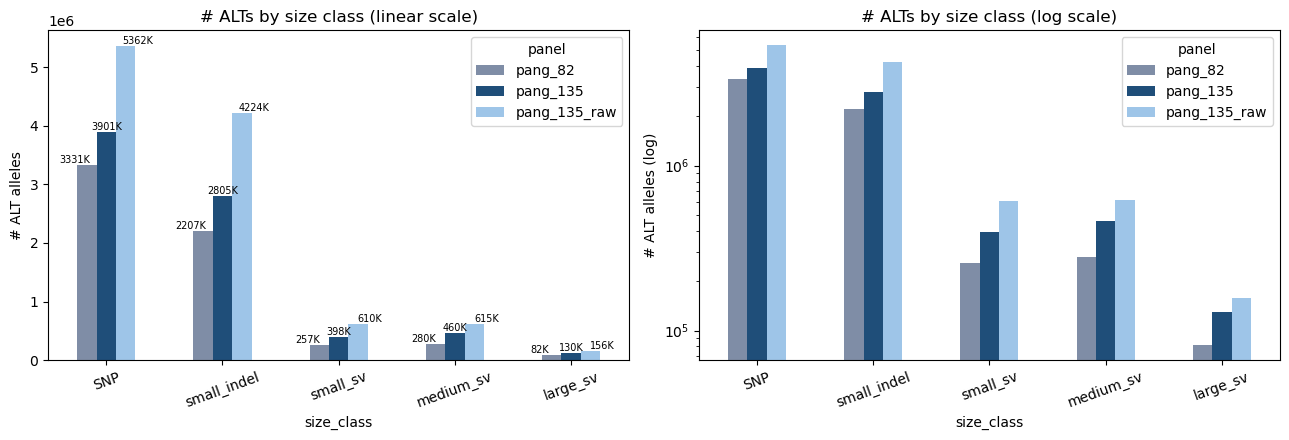

panel,pang_82,pang_135,pang_135_raw
size_class,,,
SNP,3330778,3901065,5361694
small_indel,2206540,2804632,4223985
small_sv,257476,397541,609520
medium_sv,279760,460200,614572
large_sv,81516,130120,156492


In [5]:
sc_total = (size_class_all
    .groupby(['panel','size_class'], as_index=False)['n_alts'].sum())
wide = sc_total.pivot(index='size_class', columns='panel', values='n_alts').reindex(
    ['SNP','small_indel','small_sv','medium_sv','large_sv'])
wide = wide[['pang_82','pang_135','pang_135_raw']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
wide.plot(kind='bar', ax=axes[0], color=[PANEL_COLORS[c] for c in wide.columns])
axes[0].set_title('# ALTs by size class (linear scale)')
axes[0].set_ylabel('# ALT alleles')
for c in wide.columns:
    for i, v in enumerate(wide[c]):
        axes[0].text(i + (list(wide.columns).index(c) - 1) * 0.27, v, f'{v/1e3:.0f}K',
                     ha='center', va='bottom', fontsize=7)
axes[0].tick_params(axis='x', rotation=20)

wide.plot(kind='bar', ax=axes[1], color=[PANEL_COLORS[c] for c in wide.columns])
axes[1].set_yscale('log')
axes[1].set_title('# ALTs by size class (log scale)')
axes[1].set_ylabel('# ALT alleles (log)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
wide

In [6]:
# Fold change pang_135 vs pang_82 per size class
wide_fc = wide.copy()
wide_fc['fold_135_vs_82'] = wide['pang_135'] / wide['pang_82']
wide_fc['fold_135_raw_vs_82'] = wide['pang_135_raw'] / wide['pang_82']
wide_fc['filter_drop_pct_135'] = (1 - wide['pang_135'] / wide['pang_135_raw']) * 100
wide_fc.round(2)

panel,pang_82,pang_135,pang_135_raw,fold_135_vs_82,fold_135_raw_vs_82,filter_drop_pct_135
size_class,,,,,,
SNP,3330778,3901065,5361694,1.17,1.61,27.24
small_indel,2206540,2804632,4223985,1.27,1.91,33.60
small_sv,257476,397541,609520,1.54,2.37,34.78
medium_sv,279760,460200,614572,1.64,2.20,25.12
large_sv,81516,130120,156492,1.60,1.92,16.85


## 5. Size-class × chromosome heatmap (pang_135 / pang_82 fold)

Where did pang_135 add the most variants relative to pang_82?

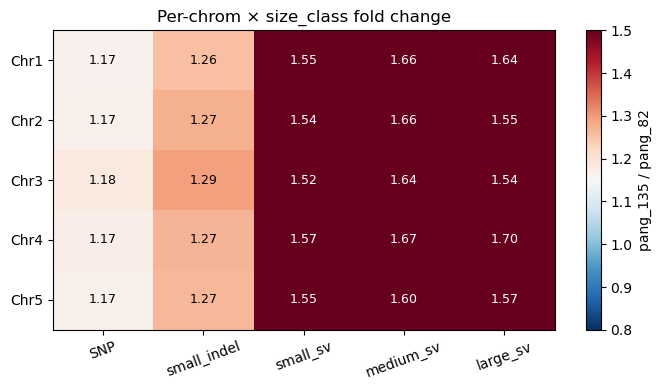

size_class,SNP,small_indel,small_sv,medium_sv,large_sv
chrom,,,,,
Chr1,1.17,1.26,1.55,1.66,1.64
Chr2,1.17,1.27,1.54,1.66,1.55
Chr3,1.18,1.29,1.52,1.64,1.54
Chr4,1.17,1.27,1.57,1.67,1.70
Chr5,1.17,1.27,1.55,1.60,1.57


In [7]:
p82 = sc_82.pivot(index='chrom', columns='size_class', values='n_alts').reindex(
    columns=['SNP','small_indel','small_sv','medium_sv','large_sv'])
p135 = sc_135.pivot(index='chrom', columns='size_class', values='n_alts').reindex(
    columns=['SNP','small_indel','small_sv','medium_sv','large_sv'])
fold = p135 / p82

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(fold.values, cmap='RdBu_r', vmin=0.8, vmax=1.5, aspect='auto')
ax.set_xticks(range(len(fold.columns))); ax.set_xticklabels(fold.columns, rotation=20)
ax.set_yticks(range(len(fold.index)));   ax.set_yticklabels(fold.index)
for i in range(fold.shape[0]):
    for j in range(fold.shape[1]):
        ax.text(j, i, f'{fold.values[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if fold.values[i,j]>1.4 or fold.values[i,j]<0.9 else 'black')
fig.colorbar(im, ax=ax, label='pang_135 / pang_82')
ax.set_title('Per-chrom × size_class fold change')
plt.tight_layout(); plt.show()
fold.round(2)

## 6. What does cactus's pre-filter drop?  (pang_135 raw - filtered)

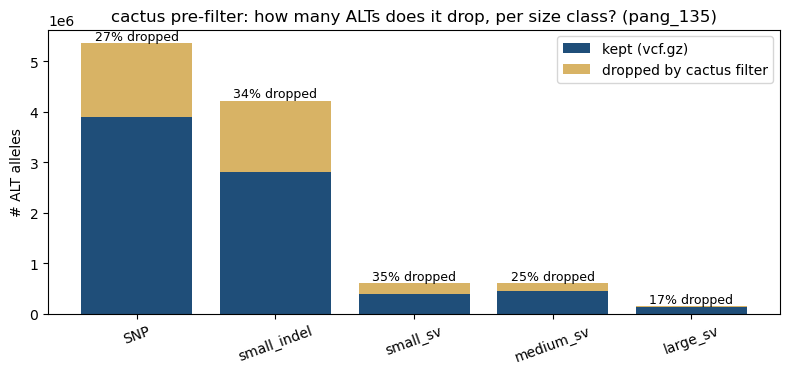

,kept,dropped,pct_dropped
size_class,,,
SNP,3901065,1460629,27.2
small_indel,2804632,1419353,33.6
small_sv,397541,211979,34.8
medium_sv,460200,154372,25.1
large_sv,130120,26372,16.9


In [8]:
drop = (sc_135_raw.set_index(['chrom','size_class'])['n_alts']
        - sc_135.set_index(['chrom','size_class'])['n_alts'])
drop = drop.reset_index().rename(columns={0:'n_alts','n_alts':'n_alts_dropped'})
drop_total = drop.groupby('size_class')['n_alts_dropped'].sum().reindex(
    ['SNP','small_indel','small_sv','medium_sv','large_sv'])
kept_total = sc_135.groupby('size_class')['n_alts'].sum().reindex(drop_total.index)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(drop_total))
ax.bar(x, kept_total.values,        color='#1f4e79', label='kept (vcf.gz)')
ax.bar(x, drop_total.values, bottom=kept_total.values,
       color='#d8b365', label='dropped by cactus filter')
ax.set_xticks(x); ax.set_xticklabels(drop_total.index, rotation=20)
ax.set_ylabel('# ALT alleles')
ax.set_title('cactus pre-filter: how many ALTs does it drop, per size class? (pang_135)')
for i, (k, d) in enumerate(zip(kept_total, drop_total)):
    pct = d / (k+d) * 100
    ax.text(i, k+d, f'{pct:.0f}% dropped', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()

pd.DataFrame({'kept': kept_total, 'dropped': drop_total,
              'pct_dropped': drop_total / (kept_total + drop_total) * 100}).round(1)

## 7. SV-subgraph topology (sv.gfa.gz)

Nodes / edges / total bases of the variant-bearing subgraph.

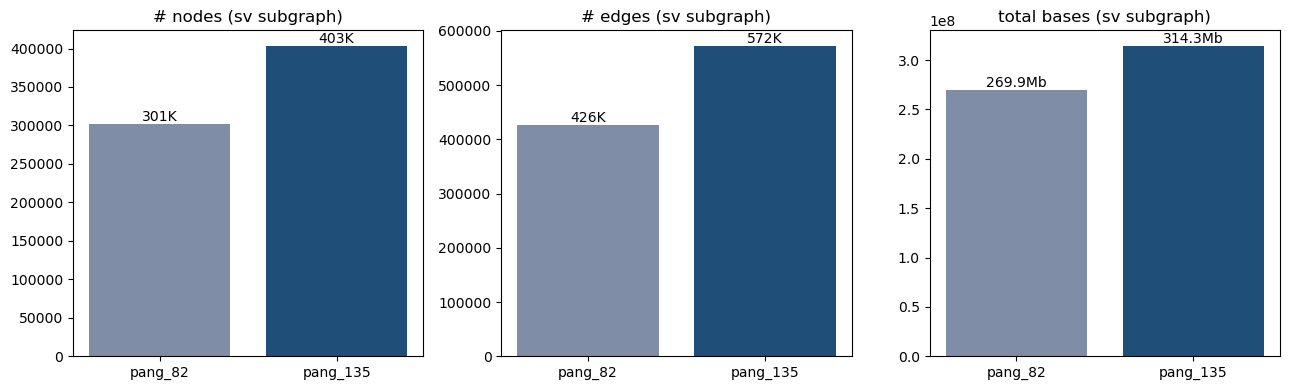

,pang_82,pang_135,fold_135_vs_82
n_nodes,301296,403455,1.339
n_edges,426228,572416,1.343
n_paths,0,0,NaN
n_walks,0,0,NaN
total_bases,269880843,314337605,1.165


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(
    axes,
    ['n_nodes', 'n_edges', 'total_bases'],
    ['# nodes (sv subgraph)', '# edges (sv subgraph)', 'total bases (sv subgraph)']):
    bars = ax.bar(gfa_topo['panel'], gfa_topo[col],
                  color=[PANEL_COLORS[p] for p in gfa_topo['panel']])
    ax.set_title(title)
    for b, v in zip(bars, gfa_topo[col]):
        ax.text(b.get_x()+b.get_width()/2, v,
                f'{v/1e3:.0f}K' if col!='total_bases' else f'{v/1e6:.1f}Mb',
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

g = gfa_topo.set_index('panel')
delta = pd.DataFrame({
    'pang_82':  g.loc['pang_82'],
    'pang_135': g.loc['pang_135'],
    'fold_135_vs_82': g.loc['pang_135'] / g.loc['pang_82'],
})
delta.round(3)

## 8. Summary one-liner

In [10]:
print(f"""
pang_82  : {panel_summary.iloc[0]['n_samples']:>4} founders, {panel_summary.iloc[0]['n_records_filtered']/1e6:>5.2f}M filtered records
pang_135 : {panel_summary.iloc[1]['n_samples']:>4} founders, {panel_summary.iloc[1]['n_records_filtered']/1e6:>5.2f}M filtered records ({float(panel_summary.iloc[1]['n_records_raw'])/1e6:.2f}M raw)
Δfounders: +{panel_summary.iloc[1]['n_samples']-panel_summary.iloc[0]['n_samples']} (+{(panel_summary.iloc[1]['n_samples']/panel_summary.iloc[0]['n_samples']-1)*100:.0f}%)
Δrecords : +{(panel_summary.iloc[1]['n_records_filtered']-panel_summary.iloc[0]['n_records_filtered'])/1e6:.2f}M (+{(panel_summary.iloc[1]['n_records_filtered']/panel_summary.iloc[0]['n_records_filtered']-1)*100:.0f}%)
ΔSV-graph nodes: {(g.loc['pang_135','n_nodes']/g.loc['pang_82','n_nodes']-1)*100:+.0f}%
Cactus filter dropped {(1-panel_summary.iloc[1]['n_records_filtered']/float(panel_summary.iloc[1]['n_records_raw']))*100:.0f}% of pang_135 raw records.
""")


pang_82  :   82 founders,  4.45M filtered records
pang_135 :  135 founders,  5.21M filtered records (7.86M raw)
Δfounders: +53 (+65%)
Δrecords : +0.76M (+17%)
ΔSV-graph nodes: +34%
Cactus filter dropped 34% of pang_135 raw records.

